In [1]:
print("Hi")

Hi


### GPT2-Small Configs and Dummy Class

In [39]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [5]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [6]:
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # A simple placeholder

    def forward(self, x):
        # This block does nothing and just returns its input.
        return x

In [7]:
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self, x):
        # This layer does nothing and just returns its input.
        return x

### Converting words to Embeddings

In [3]:
import tiktoken
import torch
tokenizer=tiktoken.get_encoding("gpt2")

batch=[]

txt1="Every effort moves you"
txt2="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
#cfg=configuration
#torch.manual_seed(123)
#model=
#logits=model(batch)
#print("Output Shape:",logits.shape)

### Normalizing Activations with Layer Normalizations

In [10]:
#Normalize outputs of given layer 
torch.manual_seed(123)
batch_example=torch.randn(2,5)
batch_example#Two samples with 5 dimensions each


tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])

In [11]:
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=layer(batch_example)
out

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

In [ ]:
out.mean(dim=0)#mean of each output tensors like mean(0.2260,0.2133),mean(0.3470,0.2394)

tensor([0.2196, 0.2932, 0.0000, 0.3707, 0.1649, 0.0000],
       grad_fn=<MeanBackward1>)

In [ ]:
out.mean(dim=1)#mean of each sample like mean(0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000)

tensor([0.1324, 0.2170], grad_fn=<MeanBackward1>)

In [15]:
mean=out.mean(dim=-1,keepdim=True)
mean

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

In [16]:
var=out.var(dim=-1,keepdim=True)
var

tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)

In [22]:
(out-mean).mean(dim=-1,keepdim=True) #is the op centered at mean

tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)

In [21]:
torch.set_printoptions(sci_mode=False)

In [23]:
normed=((out-mean)/torch.sqrt(var))
normed.var(dim=-1,keepdim=True)

tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)

### Layer Normalization Class

In [25]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()# for inheritance purposes
        self.eps=1e-5 #Prevents division by zero when computing:(0.00001)
        self.scale=nn.Parameter(torch.ones(emb_dim)) #unity matrix based on embedding dimensions
        self.shift=nn.Parameter(torch.zeros(emb_dim)) ##zero/null matrix based on embedding dimensions  #output=γ⋅xnorm​+β
    def forward(self,x):
        mean=x.mean(dim=-1,keepdim=True)
        var=x.var(dim=-1,keepdim=True,unbiased=False)
        norm_x=(x-mean)/torch.sqrt(var+self.eps)
        return self.scale*norm_x+self.shift#(1*norm_x+0) so just giving norm more space 

In [27]:
ln=LayerNorm(6)
outputs_normed=ln(out)

In [28]:
outputs_normed.mean(dim=-1,keepdim=True)

tensor([[     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)

In [30]:
outputs_normed.var(dim=-1,keepdim=True,unbiased=False)

tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)

### Implementing a Nonlinear Activations Using GELU Activation

In [31]:
#sigmoid,tanh,step,softplus,relu,elu,gelu,swish
#linear layer->gelu->linear layer
#relu:for all negatives output is stagnated at 0,for all positives it follows a straight line curve
#gelu:adapted by theoriginal developers of gpt

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self,x):
        return 0.5*x*(1+torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi))*
            (x+0.044715*torch.pow(x,3))
        ))

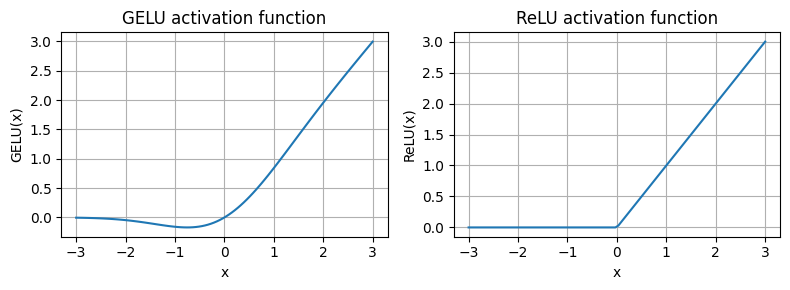

In [34]:
import matplotlib.pyplot as plt

gelu,relu=nn.GELU(),nn.ReLU()

x=torch.linspace(-3,3,100)
y_gelu,y_relu=gelu(x),relu(x)

plt.figure(figsize=(8,3))
for i,(y,label) in enumerate(zip([y_gelu,y_relu],["GELU","ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]),
        )
    def forward(self,x):
        return self.layers(x)

In [46]:
ffm=FeedForward(GPT_CONFIG_124M)

In [47]:
X=torch.rand(2,3,768)
ffm(X).shape

torch.Size([2, 3, 768])

In [49]:
ffm.layers[0].weight

Parameter containing:
tensor([[-0.0049,  0.0168,  0.0094,  ...,  0.0202, -0.0144, -0.0348],
        [-0.0340,  0.0307, -0.0139,  ..., -0.0306, -0.0121, -0.0038],
        [ 0.0001, -0.0327, -0.0342,  ...,  0.0225, -0.0184,  0.0170],
        ...,
        [ 0.0189, -0.0072, -0.0021,  ..., -0.0010,  0.0350, -0.0325],
        [ 0.0271,  0.0225, -0.0180,  ...,  0.0225, -0.0134,  0.0106],
        [ 0.0355,  0.0176,  0.0173,  ...,  0.0266, -0.0241, -0.0045]],
       requires_grad=True)

### Addition of Shortcut Connections

In [50]:
#Shortcut connections to implement transformer block
#Basically skip connections to reduce vanishing gradient


In [58]:
class ExampleDeepNeuralnetwork(nn.Module):
    def __init__(self,layer_sizes,use_shortcut):
        super().__init__()
        self.use_shortcut=use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]),nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]),nn.GELU())
        ])
    def forward(self,x):
        for layer in self.layers:
            layer_output=layer(x)
            if self.use_shortcut and x.shape==layer_output.shape:
                x=x+layer_output
            else:
                x=layer_output
        return x
def print_gradients(model,x):
    output=model(x)
    target=torch.tensor([[0.]])

    loss=nn.MSELoss()
    loss=loss(output,target)

    loss.backward()

    for name,param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [59]:
layer_sizes=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.,-1.]])

In [60]:
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralnetwork(
    layer_sizes,use_shortcut=False
)
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.0002017411752603948
layers.1.0.weight has gradient mean of 0.00012011770741082728
layers.2.0.weight has gradient mean of 0.0007152437465265393
layers.3.0.weight has gradient mean of 0.0013988513965159655
layers.4.0.weight has gradient mean of 0.005049604922533035


In [61]:
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralnetwork(
    layer_sizes,use_shortcut=True
)
print_gradients(model_without_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.22186796367168427
layers.1.0.weight has gradient mean of 0.207092747092247
layers.2.0.weight has gradient mean of 0.32923877239227295
layers.3.0.weight has gradient mean of 0.2667771875858307
layers.4.0.weight has gradient mean of 1.3268063068389893


### Connecting Attention and Linear Layers in a Transformer Block

In [62]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        assert(d_out % num_heads==0),\
            "d_out must be divisible by num_heads"
        self.d_out=d_out
        self.num_heads=num_heads
        self.head_dim=d_out//num_heads
        self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.out_proj=nn.Linear(d_out,d_out)
        self.dropout=nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length),diagonal=1)
        )
    def forward(self,x):
        b,num_tokens,d_in=x.shape
        keys=self.W_key(x)
        queries=self.W_query(x)
        values=self.W_value(x)
        keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
        values=values.view(b,num_tokens,self.num_heads,self.head_dim)
        queries=queries.view(b,num_tokens,self.num_heads,self.head_dim)

        keys=keys.transpose(1,2)
        queries=queries.transpose(1,2)
        values=values.transpose(1,2)

        attn_scores = queries @ keys.transpose(2,3)

        mask_bool=self.mask.bool()[:num_tokens,:num_tokens]
        attn_scores.masked_fill_(mask_bool,-torch.inf)

        attn_weights=torch.softmax(attn_scores/keys.shape[-1]**0.5,dim=-1)
        attn_weights=self.dropout(attn_weights)

        context_vec=(attn_weights @ values).transpose(1,2)
        context_vec=context_vec.contiguous().view(b,num_tokens,self.d_out)
        context_vec=self.out_proj(context_vec)

        return context_vec

In [64]:

class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att=MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff=FeedForward(cfg)
        self.norm1=LayerNorm(cfg["emb_dim"])
        self.norm2=LayerNorm(cfg["emb_dim"])
        self.drop_shortcut=nn.Dropout(cfg["drop_rate"])
    
    def forward(self,x):
        #Shortcut for attention block
        shortcut=x
        x=self.norm1(x)
        x=self.att(x)#masked multi head
        x=self.drop_shortcut(x)#dropout
        x=x+shortcut

        #Shortcut for Feed Forward Block
        shortcut=x
        x=self.norm2(x)#layer norm
        x=self.ff(x)#feed forward
        x=self.drop_shortcut(x)#dropout
        x=x+shortcut#add back the shortcut i.e basically performing the skip connection

        return x


In [65]:
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)

In [ ]:
output.shape#input and output shape is same

torch.Size([2, 4, 768])

### Coding the GPT Model Architecture

In [69]:
# real text->tokenized text->positional embedding layer->dropout->[layermorm1->maskedmultiheadattention->Dropout->(+)
#                                                                                                                   |
#                                                                                                                  \/                  
#                              embeddings<-Linear Output layer<-Final layernorm<-[dropout <-feed Forward <-Layernorm2

# Transformer block used 12 times as per og gpt makers

In [71]:
batch

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

In [70]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [72]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
out=model(batch)

In [73]:
batch.shape

torch.Size([2, 4])

In [74]:
out.shape

torch.Size([2, 4, 50257])

In [75]:
batch.numel()

8

In [76]:
total_params=sum(p.numel() for p in model.parameters())
total_params

163009536

In [77]:
print(f"{total_params:,}")

163,009,536


In [79]:
model.tok_emb.weight.shape

torch.Size([50257, 768])

In [80]:
print(f"{total_params-model.out_head.weight.numel():,}")

124,412,160


### Generate Text

In [95]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond=idx[:,-context_size:]
        with torch.no_grad():
            logits=model(idx_cond)
        logits=logits[:,-1,:]
        prob=torch.softmax(logits,dim=-1)  
        idx_next=torch.argmax(prob,dim=-1,keepdim=True)
        idx=torch.cat((idx,idx_next),dim=1)  
    return idx 

In [87]:
torch.argmax(torch.tensor([14,1,-2,1,15]))

tensor(4)

In [93]:
start_context="Hello, I am"

encoded=tokenizer.encode(start_context)
encoded

[15496, 11, 314, 716]

In [90]:
encoded_tensor=torch.tensor(encoded).unsqueeze(0)
encoded_tensor.shape

torch.Size([1, 4])

In [85]:
encoded_tensor

tensor([[15496,    11,   314,   716]])

In [96]:
out=generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

In [97]:
out

tensor([[15496,    11,   314,   716, 27018,  7283, 14140, 31524, 20272, 36613]])

In [102]:
tokenizer.decode((out.squeeze(0)).tolist())

'Hello, I am Feature ITPlayerBasicallyarusittered'

In [101]:
(out.squeeze(0)).tolist()

[15496, 11, 314, 716, 27018, 7283, 14140, 31524, 20272, 36613]